In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn import preprocessing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

## Data Preprocessing

In [2]:
adult = pd.read_csv('/Users/diyapatel/Documents/GitHub/Advanced-ML/Homework- 5/adult (1).csv')
adult = adult.dropna()
adult.head()
adult = adult.sample(frac=1, random_state=42).reset_index(drop=True)

In [3]:
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,56,Private,33115,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
1,25,Private,112847,HS-grad,9,Married-civ-spouse,Transport-moving,Own-child,Other,Male,0,0,40,United-States,<=50K
2,43,Private,170525,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,14344,0,40,United-States,>50K
3,32,Private,186788,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
4,39,Private,277886,Bachelors,13,Married-civ-spouse,Sales,Wife,White,Female,0,0,30,United-States,<=50K


In [4]:
# data cleaning and preprocessing

# changing ? to NaN
adult = adult.replace(r'^\s*\?\s*$', np.nan, regex=True)

#education and education num are redundant, so we can drop one of them
adult = adult.drop('education', axis=1, errors='ignore')

# target variable is income with 2 levels, so we can encode it as 0 and 1
adult['income'] = adult['income'].apply(lambda x: 1 if str(x).strip() == '>50K' else 0)

# convert gender to 0/1 (doesn't need categorical encoding since it's binary)
if "gender" in adult.columns:
    adult["gender"] = adult["gender"].apply(lambda x: 1 if str(x).strip() == "Male" else 0)

# change dtype categorical variables to category
categorical_cols = adult.select_dtypes(include='object').columns
adult[categorical_cols] = adult[categorical_cols].astype('category')


adult.head(20)

/var/folders/wk/2c1dxvcd3bzdddslqmjhrdnw0000gn/T/ipykernel_40513/2776371348.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = adult.select_dtypes(include='object').columns


,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,56,Private,33115,9,Divorced,Other-service,Unmarried,White,0,0,0,40,United-States,0
1,25,Private,112847,9,Married-civ-spouse,Transport-moving,Own-child,Other,1,0,0,40,United-States,0
2,43,Private,170525,13,Divorced,Prof-specialty,Not-in-family,White,0,14344,0,40,United-States,1
3,32,Private,186788,9,Married-civ-spouse,Transport-moving,Husband,White,1,0,0,40,United-States,0
4,39,Private,277886,13,Married-civ-spouse,Sales,Wife,White,0,0,0,30,United-States,0
5,20,Private,323009,9,Never-married,Adm-clerical,Unmarried,White,0,0,0,40,Germany,0
6,54,Private,146834,9,Divorced,Transport-moving,Not-in-family,White,1,0,0,45,United-States,0
7,25,Private,166977,13,Married-civ-spouse,Prof-specialty,Wife,White,0,0,1887,40,United-States,1
8,30,Private,209317,9,Never-married,Machine-op-inspct,Not-in-family,White,1,0,0,50,Dominican-Republic,0
9,33,Private,92865,10,Never-married,Adm-clerical,Own-child,White,0,0,0,40,United-States,0


In [5]:
# fixed train/test split for the entire notebook

train_idx, test_idx = train_test_split(
    adult.index,
    test_size=0.2,
    stratify=adult["income"],
    random_state=42
)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

Train rows: 39073
Test rows: 9769


### Encoding


In [6]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# one hot encoding low cardinality features for models that don't handle categorical variables natively
import category_encoders as ce
adult_ohe = adult.copy()

adult_ohe = pd.get_dummies(
    adult_ohe,
    columns=["marital-status", "relationship", "race", "workclass"],
    drop_first=True, dtype = int
)

# target encoding for screening only 
occupation_encoder = ce.TargetEncoder(cols=["occupation"])
adult_ohe["occupation_encoded"] = occupation_encoder.fit_transform(
    adult_ohe[["occupation"]], adult_ohe["income"]
)["occupation"]

native_country_encoder = ce.TargetEncoder(cols=["native-country"])
adult_ohe["native_country_encoded"] = native_country_encoder.fit_transform(
    adult_ohe[["native-country"]], adult_ohe["income"]
)["native-country"]

adult_ohe.head()

,age,fnlwgt,educational-num,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,income,...,race_White,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_encoded,native_country_encoded
0,56,33115,9,Other-service,0,0,0,40,United-States,0,...,1,0,0,1,0,0,0,0,0.041438,0.243977
1,25,112847,9,Transport-moving,1,0,0,40,United-States,0,...,0,0,0,1,0,0,0,0,0.204246,0.243977
2,43,170525,13,Prof-specialty,0,14344,0,40,United-States,1,...,1,0,0,1,0,0,0,0,0.451069,0.243977
3,32,186788,9,Transport-moving,1,0,0,40,United-States,0,...,1,0,0,1,0,0,0,0,0.204246,0.243977
4,39,277886,13,Sales,0,0,0,30,United-States,0,...,1,0,0,1,0,0,0,0,0.267987,0.243977


In [ ]:
# Define X by dropping target and raw categorical/unwanted columns
X = adult_ohe.drop(
    columns=["income", "occupation", "native-country", "fnlwgt", "education"], 
    errors="ignore"
)

# Define y 
y = adult_ohe["income"]

# Split using the train_idx and test_idx 
X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]


### Feature Engineering

In [ ]:
# Create the interaction feature on the split data
X_train["married_occ_interaction"] = (
    X_train["marital-status_Married-civ-spouse"] * X_train["occupation_encoded"]
)
X_test["married_occ_interaction"] = (
    X_test["marital-status_Married-civ-spouse"] * X_test["occupation_encoded"]
)

# Print to verify the interaction column is present
print("Married interaction column in train:", "married_occ_interaction" in X_train.columns)
print("Train shape:", X_train.shape)



Married interaction column in train: True
Train shape: (39073, 31)


### Feature Scaling 



In [ ]:
# Scale features using StandardScaler fitted on training set only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

print("Scaled training features shape:", X_train_scaled.shape)

Scaled training features shape: (39073, 31)


## Building the Neural Network

### Baseline Neural Network

In [12]:
#construct the model
tf.random.set_seed(42)
# Using X_train_scaled.shape[1] dynamically sets the input shape to 31
inputs = keras.Input(shape=(X_train_scaled.shape[1],))
x = layers.Dense(32, activation="relu")(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
# Define the model (naming it 'income_model')
model = keras.Model(inputs=inputs, outputs=outputs, name="income_model")
model.summary()

Model: "income_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.summary()

Model: "income_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compiling for binary classification (income <=50K vs >50K)
model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=["accuracy"],
)

history = model.fit(
    X_train_scaled, 
    y_train, 
    batch_size=64, 
    epochs=100, 
    validation_split=0.2,
    verbose=1
)

test_scores = model.evaluate(X_test_scaled, y_test, verbose=2)
print(f"\nTest Loss: {test_scores[0]:.4f}")
print(f"Test Accuracy: {test_scores[1]:.4f}")

Epoch 1/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step - accuracy: 0.8339 - loss: 0.3643 - val_accuracy: 0.8495 - val_loss: 0.3282
Epoch 2/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.8497 - loss: 0.3202 - val_accuracy: 0.8513 - val_loss: 0.3222
Epoch 3/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.8524 - loss: 0.3148 - val_accuracy: 0.8523 - val_loss: 0.3202
Epoch 4/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.8540 - loss: 0.3122 - val_accuracy: 0.8526 - val_loss: 0.3194
Epoch 5/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - accuracy: 0.8546 - loss: 0.3104 - val_accuracy: 0.8537 - val_loss: 0.3189
Epoch 6/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - accuracy: 0.8556 - loss: 0.3093 - val_accuracy: 0.8534 - val_loss: 0.3185
Epoch 7/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - accuracy: 0.8560 - loss: 0.3085 - val_accuracy: 0.8525 - val_loss: 0.3184
Epoch 8/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.8564 - loss: 0

In [ ]:
# Rebuild inputs and outputs for the income dataset (31 features -> 1 output)
inputs = keras.Input(shape=(X_train_scaled.shape[1],))
x = layers.Dense(32, activation='relu')(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_logit_false = keras.Model(inputs=inputs, outputs=outputs, name="income_model_scaled")

# Change loss to BinaryCrossentropy
model_logit_false.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history_logit_false = model_logit_false.fit(
    X_train_scaled, 
    y_train, 
    batch_size=50, 
    epochs=60, 
    validation_split=0.3
)

scores = model_logit_false.evaluate(X_test_scaled, y_test, verbose=2)


Epoch 1/60
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - accuracy: 0.8204 - loss: 0.3698 - val_accuracy: 0.8482 - val_loss: 0.3260
Epoch 2/60
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.8492 - loss: 0.3216 - val_accuracy: 0.8505 - val_loss: 0.3187
Epoch 3/60
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - accuracy: 0.8509 - loss: 0.3163 - val_accuracy: 0.8513 - val_loss: 0.3171
Epoch 4/60
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - accuracy: 0.8522 - loss: 0.3135 - val_accuracy: 0.8519 - val_loss: 0.3166
Epoch 5/60
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.8536 - loss: 0.3117 - val_accuracy: 0.8519 - val_loss: 0.3167
Epoch 6/60
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.8545 - loss: 0.3107 - val_accuracy: 0.8513 - val_loss: 0.3167
Epoch 7/60
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.8551 - loss: 0.3099 - val_accuracy: 0.8519 - val_loss: 0.3168
Epoch 8/60
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.8554 - loss: 0.3093 - 

In [16]:
model_logit_false.predict(X_train_scaled)

1222/1222 ━━━━━━━━━━━━━━━━━━━━ 0s 300us/step


array([[0.00531828],
       [0.12362498],
       [0.12509416],
       ...,
       [0.30468976],
       [0.00091635],
       [0.00080681]], shape=(39073, 1), dtype=float32)

In [17]:
y_train

34409    0.0
18537    0.0
12495    0.0
561      0.0
3450     0.0
        ... 
37982    1.0
16347    1.0
26691    1.0
20603    0.0
42597    0.0
Name: income, Length: 39073, dtype: float32

In [18]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


### Evaluation

In [19]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step

 Test Set Evaluation:
Test Accuracy: 0.7607
Test Precision: 0.5786
Test Recall: 0.7607
Test F1 Score: 0.6573
Test ROC AUC Score: 0.9082


/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


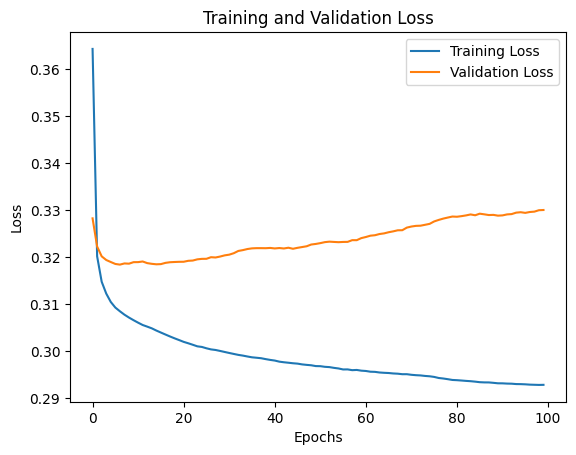

In [20]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

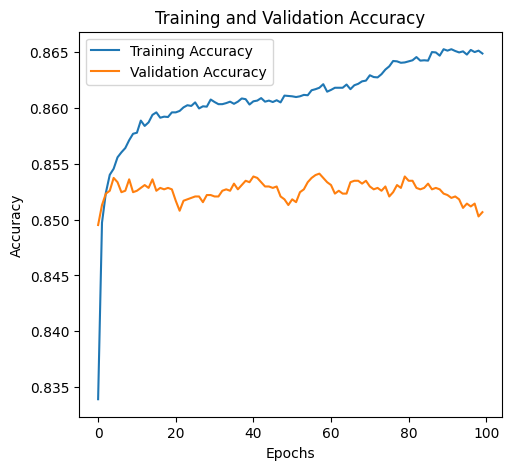

In [21]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend() 

### Conguration 1: Wide Flat Architecture 

In [ ]:
# Config 1: Wide Flat (32 -> 32)
tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train_scaled.shape[1],))
x = layers.Dense(32, activation = 'relu')(inputs)
x = layers.Dense(32, activation = 'relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(inputs=inputs, outputs=outputs, name="wide_flat_model")

model_1.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history_1 = model_1.fit(
    X_train_scaled, 
    y_train, 
    batch_size=128, 
    epochs=20, 
    validation_split=0.2, 
    verbose=1
)

scores_1 = model_1.evaluate(X_test_scaled, y_test, verbose=1)
print(f'Config 1 Test Loss: {scores_1[0]:.4f}, Test Accuracy: {scores_1[1]:.4f}')


Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8235 - loss: 0.3826 - val_accuracy: 0.8415 - val_loss: 0.3288
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.8486 - loss: 0.3240 - val_accuracy: 0.8493 - val_loss: 0.3198
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - accuracy: 0.8523 - loss: 0.3162 - val_accuracy: 0.8512 - val_loss: 0.3170
Epoch 4/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - accuracy: 0.8535 - loss: 0.3122 - val_accuracy: 0.8511 - val_loss: 0.3162
Epoch 5/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.8543 - loss: 0.3098 - val_accuracy: 0.8507 - val_loss: 0.3159
Epoch 6/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.8550 - loss: 0.3081 - val_accuracy: 0.8508 - val_loss: 0.3156
Epoch 7/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - accuracy: 0.8558 - loss: 0.3070 - val_accuracy: 0.8517 - val_loss: 0.3154
Epoch 8/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.8563 - loss: 0.3060 - va

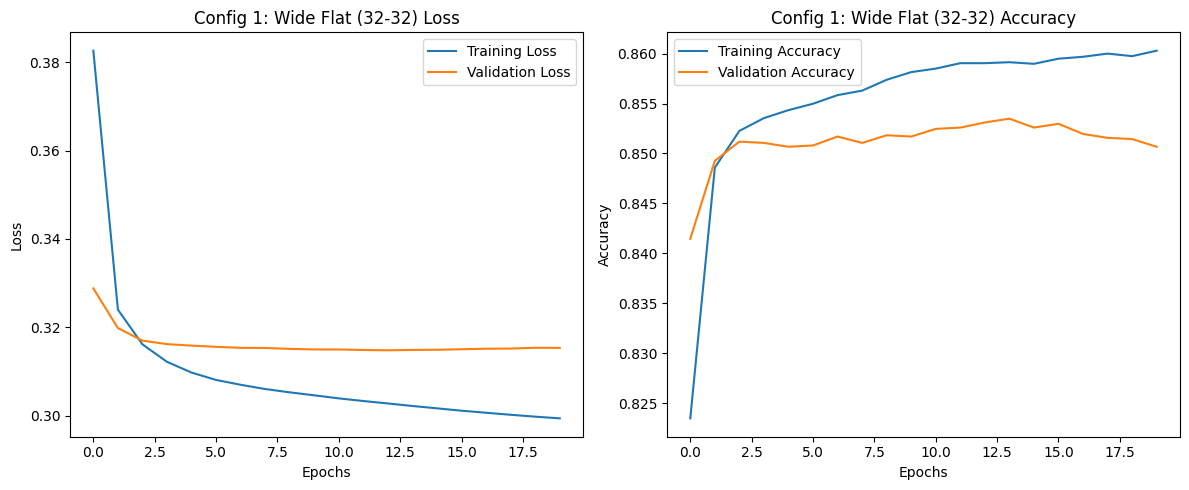

In [23]:
# Config 1 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_1.history['loss'], label='Training Loss')
axes[0].plot(history_1.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Config 1: Wide Flat (32-32) Loss')
axes[0].legend()

axes[1].plot(history_1.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_1.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Config 1: Wide Flat (32-32) Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

### Configuration 2: Deep Funnel Architecture 

In [ ]:
# Config 2: Deep Funnel (64 -> 32 -> 16)
tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train_scaled.shape[1],))
x = layers.Dense(64, activation = 'relu')(inputs)
x = layers.Dense(32, activation = 'relu')(x)
x = layers.Dense(16, activation = 'relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(inputs=inputs, outputs=outputs, name="deep_funnel_model")

model_2.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history_2 = model_2.fit(
    X_train_scaled, 
    y_train, 
    batch_size=128, 
    epochs=50, 
    validation_split=0.2, 
    verbose=1
)

scores_2 = model_2.evaluate(X_test_scaled, y_test, verbose=1)
print(f'Config 2 Test Loss: {scores_2[0]:.4f}, Test Accuracy: {scores_2[1]:.4f}')


Epoch 1/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7943 - loss: 0.4208 - val_accuracy: 0.8462 - val_loss: 0.3290
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.8498 - loss: 0.3205 - val_accuracy: 0.8486 - val_loss: 0.3218
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.8522 - loss: 0.3135 - val_accuracy: 0.8491 - val_loss: 0.3196
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.8535 - loss: 0.3102 - val_accuracy: 0.8503 - val_loss: 0.3185
Epoch 5/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.8557 - loss: 0.3080 - val_accuracy: 0.8507 - val_loss: 0.3177
Epoch 6/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.8564 - loss: 0.3060 - val_accuracy: 0.8507 - val_loss: 0.3171
Epoch 7/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.8573 - loss: 0.3043 - val_accuracy: 0.8521 - val_loss: 0.3167
Epoch 8/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - accuracy: 0.8585 - loss: 0.3028 - va

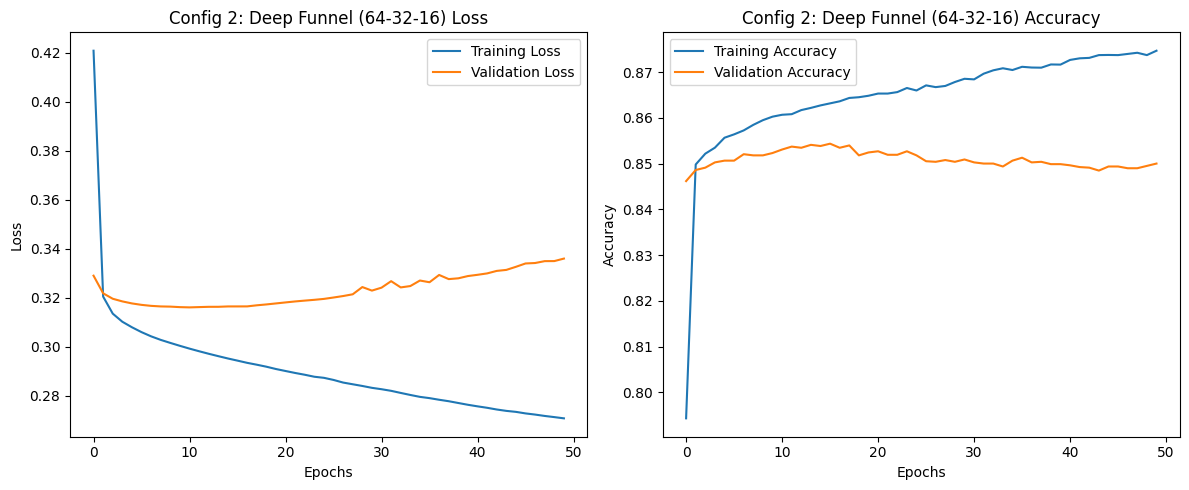

In [25]:
# Config 2 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_2.history['loss'], label='Training Loss')
axes[0].plot(history_2.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Config 2: Deep Funnel (64-32-16) Loss')
axes[0].legend()

axes[1].plot(history_2.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_2.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Config 2: Deep Funnel (64-32-16) Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

### Conguration 3: Single Layer Architecture

In [ ]:
# Config 3: Single Layer (16)
tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train_scaled.shape[1],))
x = layers.Dense(16, activation = 'relu')(inputs)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_3 = keras.Model(inputs=inputs, outputs=outputs, name="single_layer_model")

model_3.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history_3 = model_3.fit(
    X_train_scaled, 
    y_train, 
    batch_size=128, 
    epochs=10, 
    validation_split=0.2, 
    verbose=1
)

scores_3 = model_3.evaluate(X_test_scaled, y_test, verbose=1)
print(f'Config 3 Test Loss: {scores_3[0]:.4f}, Test Accuracy: {scores_3[1]:.4f}')


Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8092 - loss: 0.4135 - val_accuracy: 0.8349 - val_loss: 0.3464
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - accuracy: 0.8399 - loss: 0.3401 - val_accuracy: 0.8438 - val_loss: 0.3325
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.8442 - loss: 0.3296 - val_accuracy: 0.8466 - val_loss: 0.3265
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - accuracy: 0.8480 - loss: 0.3234 - val_accuracy: 0.8488 - val_loss: 0.3227
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - accuracy: 0.8510 - loss: 0.3191 - val_accuracy: 0.8489 - val_loss: 0.3200
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.8516 - loss: 0.3160 - val_accuracy: 0.8499 - val_loss: 0.3182
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8522 - loss: 0.3139 - val_accuracy: 0.8491 - val_loss: 0.3171
Epoch 8/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8528 - loss: 0.3124 - val_ac

### Evaluation of final model on held-out test set

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step
Test Loss:      0.3105
Accuracy:       0.8586
Precision:      0.7450
Recall:         0.6223
F1 Score:       0.6782
ROC-AUC Score:  0.9109


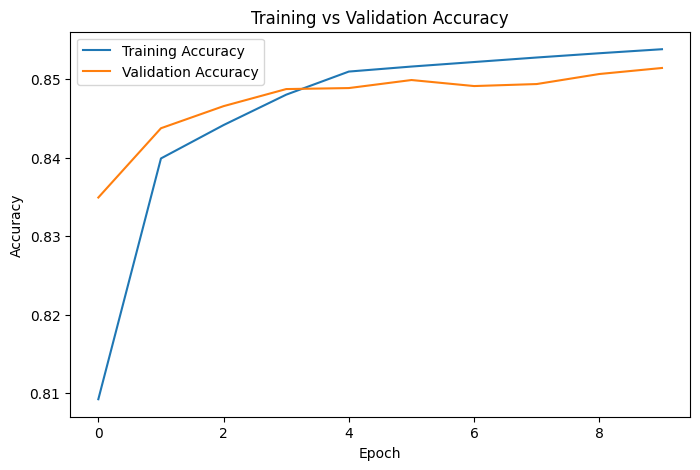

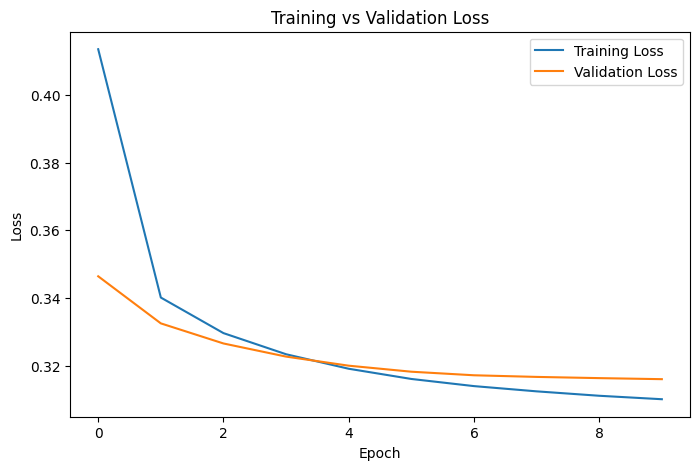

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

test_loss, test_accuracy = model_3.evaluate(X_test_scaled, y_test, verbose=0)

# Predicted probabilities
y_pred_prob = model_3.predict(X_test_scaled).ravel()

# Convert probabilities to class labels
y_pred = (y_pred_prob >= 0.5).astype(int)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"Test Loss:      {test_loss:.4f}")
print(f"Accuracy:       {accuracy:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1 Score:       {f1:.4f}")
print(f"ROC-AUC Score:  {auc:.4f}")


# Training vs validation behavior
plt.figure(figsize=(8, 5))
plt.plot(history_3.history["accuracy"], label="Training Accuracy")
plt.plot(history_3.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_3.history["loss"], label="Training Loss")
plt.plot(history_3.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

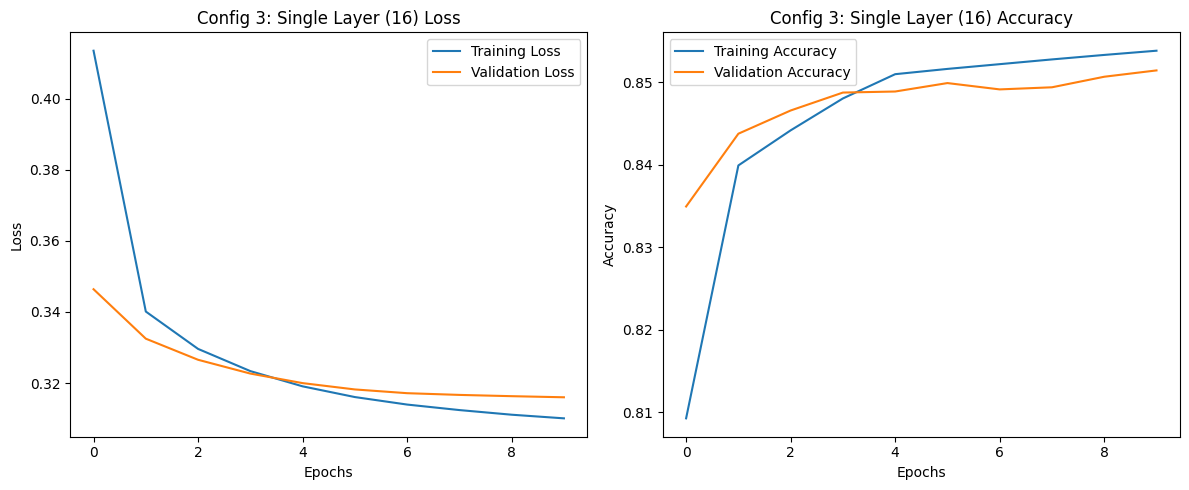

In [27]:
# Config 3 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_3.history['loss'], label='Training Loss')
axes[0].plot(history_3.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Config 3: Single Layer (16) Loss')
axes[0].legend()

axes[1].plot(history_3.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_3.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Config 3: Single Layer (16) Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

### Early stopping, L2 Regularization and dropout

In [ ]:
# early stopping, L2 Regularization and dropout

# sample model 

tf.random.set_seed(42)

# Define model architecture with L2 regularization and Dropout
inputs = keras.Input(shape=(X_train_scaled.shape[1],))

# First hidden layer (32 units) + L2 Regularization + Dropout (20%)
x = layers.Dense(
    32, 
    activation='relu', 
    kernel_regularizer=keras.regularizers.l2(0.001)
)(inputs)
x = layers.Dropout(0.2)(x)

# Second hidden layer (16 units) + L2 Regularization + Dropout (20%)
x = layers.Dense(
    16, 
    activation='relu', 
    kernel_regularizer=keras.regularizers.l2(0.001)
)(x)
x = layers.Dropout(0.2)(x)

# Output layer for binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="regularized_model")

# Compile model 
model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# Setup Early Stopping 
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 20% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)


Epoch 1/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8146 - loss: 0.4446 - val_accuracy: 0.8472 - val_loss: 0.3684
Epoch 2/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.8435 - loss: 0.3740 - val_accuracy: 0.8495 - val_loss: 0.3499
Epoch 3/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - accuracy: 0.8463 - loss: 0.3565 - val_accuracy: 0.8500 - val_loss: 0.3418
Epoch 4/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.8499 - loss: 0.3496 - val_accuracy: 0.8496 - val_loss: 0.3370
Epoch 5/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - accuracy: 0.8500 - loss: 0.3419 - val_accuracy: 0.8502 - val_loss: 0.3337
Epoch 6/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - accuracy: 0.8520 - loss: 0.3377 - val_accuracy: 0.8503 - val_loss: 0.3313
Epoch 7/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - accuracy: 0.8527 - loss: 0.3338 - val_accuracy: 0.8523 - val_loss: 0.3298
Epoch 8/100
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.8529 - loss: 0.3

### Tuning with Optuna

In [29]:
# tuning the model with Optuna (faster version)
import optuna

tf.random.set_seed(42)

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128])  # larger batches = faster

    inputs = keras.Input(shape=(X_train_scaled.shape[1],))
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 8, 64)
        x = layers.Dense(units, activation="relu")(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        loss=keras.losses.BinaryCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,  # reduced from 5 to 3 (stops sooner)
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=30,  # reduced from 100 to 30
        validation_split=0.2,
        verbose=0,
        callbacks=[early_stop]
    )

    return min(history.history["val_loss"])


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)  # reduced from 30 to 15

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-21 10:29:22,725] A new study created in memory with name: no-name-8a9ecede-f7fb-4bbe-a9da-927a0e3a6a52
[I 2026-05-21 10:29:26,062] Trial 0 finished with value: 0.3161188066005707 and parameters: {'num_layers': 1, 'learning_rate': 0.005417918393177136, 'batch_size': 128, 'num_units_layer_1': 58}. Best is trial 0 with value: 0.3161188066005707.
[I 2026-05-21 10:29:32,372] Trial 1 finished with value: 0.31368792057037354 and parameters: {'num_layers': 3, 'learning_rate': 0.007315731580182671, 'batch_size': 64, 'num_units_layer_1': 15, 'num_units_layer_2': 24, 'num_units_layer_3': 44}. Best is trial 1 with value: 0.31368792057037354.
[I 2026-05-21 10:29:36,661] Trial 2 finished with value: 0.31516286730766296 and p

Best validation loss: 0.3120681643486023
Best parameters: {'num_layers': 1, 'learning_rate': 0.0005490022103869334, 'batch_size': 64, 'num_units_layer_1': 47}


In [ ]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [30]:
# visualizing Optuna results
import plotly 
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

## Personal Workflow



The workflow I went through to building a neural network that yielded the highest accuracy first started with data processing. Here, I made sure to drop NA values, replace ? with 'unknown' and shuffle the data so the vector does not appear to be ordered, tabular data. I also pulled from previous data preprocessing steps to encode categories using categorical encoders, engineered features by creating interaction terms, and then scaling the data using StandardScaler to make sure those features are all normalized to continue on with building a baseline neural network. After building a baseline neural network using Keras, it gave me a clear starting point of where my model is in terms of performance metrics and how I can leverage it using different layers and architectures or changing basic parameters and seeing if that has any difference in my accuracy. I went through three different configurations, each using different architectures. In the first configuration, I used a wide flat architecture which has relatively large layers but only a few of them. It uses two hidden layers with 32 neurons to learn patterns in the dataset, where the first layer learns basic relationships between features while the second combines those learned patterns into more complex relationships. While this configuration performed significantly better than baseline, I also experimented using a Deep Funnel architecture with hidden layers of 64, 32, and 16 neurons which allows the model to gradually narrow and refine the information as it learns more complex patterns. This model performed significantly worse than config 1, so I also tried a single layer architecture. This was a simple single hidden layer with 16 neurons to learn the most important patterns and classify. I chose this model to evaluate on as it achieved the highest accuracy score while maintaining a simpler architecture, which reduced the risk of overfitting and generalized well to the held out test set. I also experimented with early stopping, which monitored the validation loss during training and stopped the model when performance no longer improves to prevent unnecessary training. L2 Regularization added a penalty to large weight values to push the network to learn simpler and more generalizable patterns instead of memorizing the training data. Dropout randomly turned off a percentage of neurons during training, and forced the model to rely on multiple pathways to reduce overfitting. Lastly, I used Optuna for tuning. Here, I found the loss rate to be greater than the loss rate of config 3, which did not perform as well given the plots and the results it yielded. I learned its important to experiment with many architectures, adjust epoch sizes, as well as defining the activation output as sigmoid can boost model performance depending on the type of classification problem I am given. 